# Day 2 — Cross-Validation
## Students Performance Prediction

### Objective

The objective of this notebook is to evaluate a classification model
using reliable cross-validation rather than relying on a single
validation split.

We will use the Students Performance dataset and construct a binary
target called `math_pass`, where:

- 1 = student achieved a mathematics score of 60 or higher
- 0 = student achieved a mathematics score below 60

The main goals are to:

1. Establish a baseline using a single train/test split.
2. Apply 5-fold Stratified Cross-Validation.
3. Calculate the mean and standard deviation of the F1 score.
4. Verify that class proportions remain reasonably balanced across folds.
5. Compare the single-split result with the cross-validated estimate.
6. Explain why cross-validation provides a more reliable estimate.

### Evaluation Principle

The test set will remain untouched during model evaluation with
cross-validation. Cross-validation will be performed only on the
training data.

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42

## 1. Loading the Dataset

The dataset contains student demographic, educational, and performance
information.

Before building the model, the dataset will be inspected for its
structure, data types, missing values, and class distribution.

In [36]:
df = pd.read_csv("StudentsPerformance.csv")

print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [37]:
print("Dataset information:")
df.info()

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [38]:
print("\nMissing values:")
display(df.isnull().sum())


Missing values:


gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [39]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [40]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,1000,2,female,518,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race/ethnicity,1000,5,group C,319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
parental level of education,1000,6,some college,226,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lunch,1000,2,standard,645,NaN,NaN,NaN,NaN,NaN,NaN,NaN
test preparation course,1000,2,none,642,NaN,NaN,NaN,NaN,NaN,NaN,NaN
math score,1000.0,NaN,NaN,NaN,66.089,15.16308,0.0,57.0,66.0,77.0,100.0
reading score,1000.0,NaN,NaN,NaN,69.169,14.600192,17.0,59.0,70.0,79.0,100.0
writing score,1000.0,NaN,NaN,NaN,68.054,15.195657,10.0,57.75,69.0,79.0,100.0


### Initial Inspection

The dataset contains 1,000 student records and 8 original columns.

The dataset includes categorical variables describing demographic and
educational characteristics, as well as three numerical score columns.

The inspection confirms that the dataset is suitable for a classification
task after creating a binary target from the mathematics score.

No missing-value problem should be silently assumed; therefore, missing
values and duplicates are explicitly checked before modeling.

In [42]:
df["math_pass"] = (df["math score"] >= 60).astype(int)

display(
    df["math_pass"]
    .value_counts()
    .rename(index={0: "Fail", 1: "Pass"})
)

math_pass
Pass    677
Fail    323
Name: count, dtype: int64

In [43]:
class_distribution = (
    df["math_pass"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

display(class_distribution)

math_pass
0    32.3
1    67.7
Name: proportion, dtype: float64

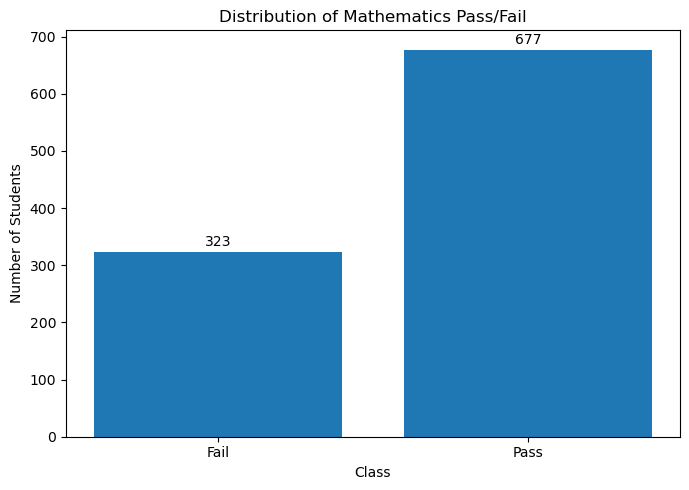

In [44]:
class_counts = df["math_pass"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(
    ["Fail", "Pass"],
    class_counts.values
)

plt.title("Distribution of Mathematics Pass/Fail")
plt.xlabel("Class")
plt.ylabel("Number of Students")

for i, value in enumerate(class_counts.values):
    plt.text(i, value + 10, str(value), ha="center")

plt.tight_layout()
plt.show()

### Interpretation

The target distribution shows how many students fall into the passing
and failing classes.

This step is important before using cross-validation because classification
folds should preserve the class distribution as closely as possible.

If the classes were strongly imbalanced, ordinary K-Fold splitting could
produce folds with noticeably different class proportions. Stratified
K-Fold addresses this issue by preserving the class distribution across
folds.

In [45]:
feature_columns = [
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course"
]

X = df[feature_columns]
y = df["math_pass"]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,gender,race/ethnicity,parental level of education,lunch,test preparation course
0,female,group B,bachelor's degree,standard,none
1,female,group C,some college,standard,completed
2,female,group B,master's degree,standard,none
3,male,group A,associate's degree,free/reduced,none
4,male,group C,some college,standard,none



Target:


0    1
1    1
2    1
3    0
4    1
Name: math_pass, dtype: int64

### Feature Selection Decision

The mathematics score is not included as an input feature because it was
used to construct the target variable.

Reading and writing scores are also excluded from this Day 2 classification
experiment. This keeps the prediction task focused on demographic,
educational, and preparation-related variables rather than using other
academic scores that may provide direct information about overall student
performance.

The selected features represent information that could reasonably be
available before observing the mathematics outcome.

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 800
Test samples: 200


In [47]:
print("Overall class distribution:")
print(y.value_counts(normalize=True).sort_index())

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Overall class distribution:
math_pass
0    0.323
1    0.677
Name: proportion, dtype: float64

Training class distribution:
math_pass
0    0.3225
1    0.6775
Name: proportion, dtype: float64

Test class distribution:
math_pass
0    0.325
1    0.675
Name: proportion, dtype: float64


### Why Stratify the Initial Split?

The initial train/test split uses `stratify=y` so that the training and
test sets retain approximately the same class distribution as the full
dataset.

The test set is held out and will not be used during cross-validation or
model selection.

In [48]:
categorical_features = X_train.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [49]:
model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

In [50]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [51]:
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.7150
Precision: 0.7378
Recall   : 0.8963
F1 Score : 0.8094


In [52]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Fail", "Pass"],
    zero_division=0
))

              precision    recall  f1-score   support

        Fail       0.61      0.34      0.44        65
        Pass       0.74      0.90      0.81       135

    accuracy                           0.71       200
   macro avg       0.67      0.62      0.62       200
weighted avg       0.70      0.71      0.69       200



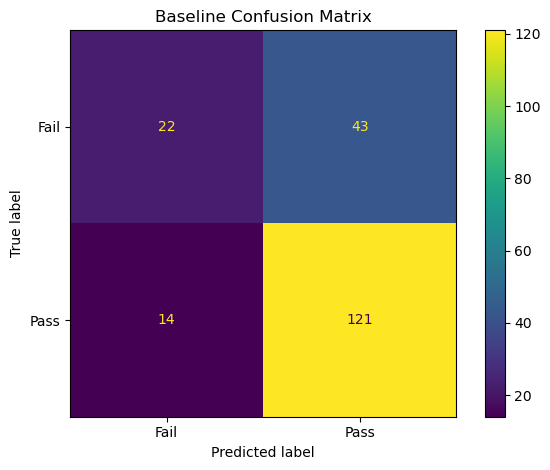

In [53]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fail", "Pass"]
)

disp.plot()
plt.title("Baseline Confusion Matrix")
plt.tight_layout()
plt.show()

### Baseline Interpretation

The single train/test split provides an initial estimate of model
performance.

However, this score depends on one particular division of the training
data. A different split could produce a different result.

Therefore, this score should be treated as a baseline rather than the
final reliability estimate. Cross-validation will evaluate the model
across multiple training/validation configurations.

In [54]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

## 2. Five-Fold Stratified Cross-Validation

Five-fold cross-validation divides the training data into five folds.

For each iteration:

- Four folds are used for training.
- One fold is used for validation.
- The process is repeated five times.
- Every training observation is used for validation exactly once.

Stratification ensures that each validation fold maintains a similar
proportion of the two target classes.

The mean F1 score will be used as the main performance estimate, while
the standard deviation will measure stability across folds.

In [55]:
cv_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=skf,
    scoring="f1"
)

print("F1 score for each fold:")
for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nMean F1: {cv_scores.mean():.4f}")
print(f"Std F1 : {cv_scores.std():.4f}")

F1 score for each fold:
Fold 1: 0.8201
Fold 2: 0.8080
Fold 3: 0.7807
Fold 4: 0.7851
Fold 5: 0.8083

Mean F1: 0.8004
Std F1 : 0.0150


In [56]:
cv_results = pd.DataFrame({
    "Fold": np.arange(1, 6),
    "F1 Score": cv_scores
})

display(cv_results)

,Fold,F1 Score
0,1,0.820084
1,2,0.808000
2,3,0.780702
3,4,0.785124
4,5,0.808333


In [57]:
print(
    f"Cross-Validation F1 = "
    f"{cv_scores.mean():.4f} ± {cv_scores.std():.4f}"
)

Cross-Validation F1 = 0.8004 ± 0.0150


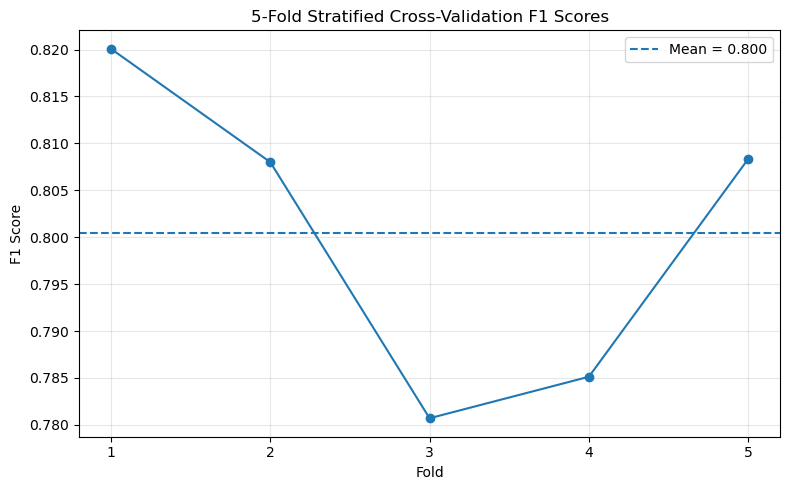

In [58]:
plt.figure(figsize=(8, 5))

plt.plot(
    cv_results["Fold"],
    cv_results["F1 Score"],
    marker="o"
)

plt.axhline(
    cv_scores.mean(),
    linestyle="--",
    label=f"Mean = {cv_scores.mean():.3f}"
)

plt.title("5-Fold Stratified Cross-Validation F1 Scores")
plt.xlabel("Fold")
plt.ylabel("F1 Score")
plt.xticks(range(1, 6))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Fold Stability Interpretation

The five fold scores show how the model performs under different
training/validation partitions.

The mean represents the overall cross-validated performance estimate,
while the standard deviation indicates how much performance changes
between folds.

A smaller standard deviation indicates that the model is less sensitive
to the particular subset used for validation.

In [59]:
print("Overall training distribution:")
display(
    y_train.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .rename({0: "Fail %", 1: "Pass %"})
)

Overall training distribution:


math_pass
Fail %    32.25
Pass %    67.75
Name: proportion, dtype: float64

In [63]:
fold_distribution = []

for fold_number, (_, val_idx) in enumerate(
    skf.split(X_train, y_train),
    start=1
):
    y_val_fold = y_train.iloc[val_idx]

    distribution = y_val_fold.value_counts(normalize=True)

    fold_distribution.append({
        "Fold": fold_number,
        "Fail %": distribution.get(0, 0) * 100,
        "Pass %": distribution.get(1, 0) * 100
    })

fold_distribution = pd.DataFrame(fold_distribution)

display(fold_distribution)

,Fold,Fail %,Pass %
0,1,31.875,68.125
1,2,31.875,68.125
2,3,32.500,67.500
3,4,32.500,67.500
4,5,32.500,67.500


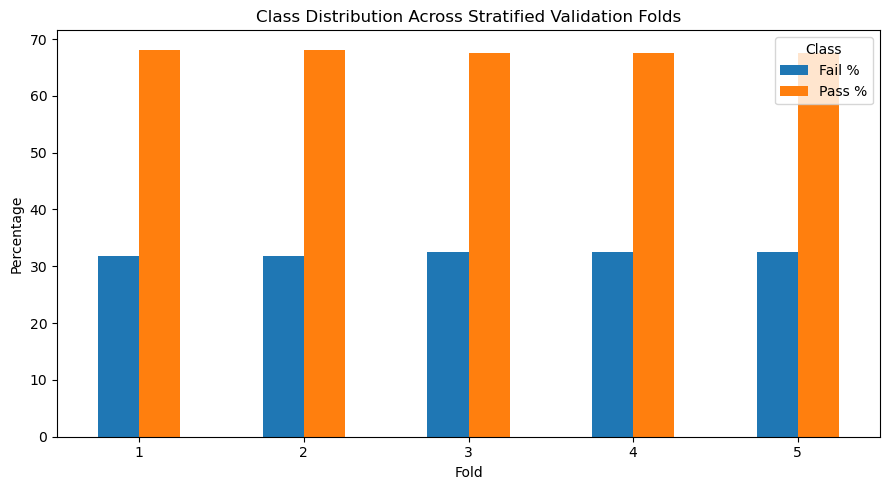

In [64]:
fold_distribution.set_index("Fold")[["Fail %", "Pass %"]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Class Distribution Across Stratified Validation Folds")
plt.xlabel("Fold")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Class")
plt.tight_layout()
plt.show()

In [65]:
print("Overall training distribution:")
display(
    y_train.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .rename({0: "Fail %", 1: "Pass %"})
)

Overall training distribution:


math_pass
Fail %    32.25
Pass %    67.75
Name: proportion, dtype: float64

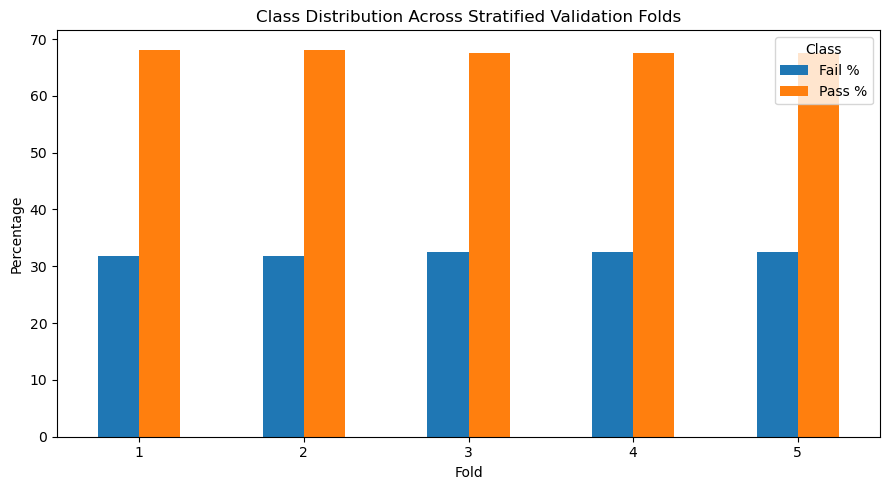

In [66]:
fold_distribution.set_index("Fold")[["Fail %", "Pass %"]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Class Distribution Across Stratified Validation Folds")
plt.xlabel("Fold")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Class")
plt.tight_layout()
plt.show()

### Stratification Verification

The class proportions across the five validation folds remain close to
the overall training distribution.

This confirms that StratifiedKFold is preserving the target distribution
while rotating the validation fold.

This is preferable to ordinary K-Fold for this classification problem,
because an unstratified split could produce folds with noticeably
different class proportions.

In [67]:
comparison = pd.DataFrame({
    "Evaluation Method": [
        "Single Test Split",
        "5-Fold Stratified CV"
    ],
    "F1 Mean": [
        f1,
        cv_scores.mean()
    ],
    "F1 Std": [
        np.nan,
        cv_scores.std()
    ]
})

display(comparison)

,Evaluation Method,F1 Mean,F1 Std
0,Single Test Split,0.809365,NaN
1,5-Fold Stratified CV,0.800449,0.01503


In [68]:
comparison = pd.DataFrame({
    "Evaluation Method": [
        "Single Test Split",
        "5-Fold Stratified CV"
    ],
    "F1 Mean": [
        f1,
        cv_scores.mean()
    ],
    "F1 Std": [
        np.nan,
        cv_scores.std()
    ]
})

display(comparison)

,Evaluation Method,F1 Mean,F1 Std
0,Single Test Split,0.809365,NaN
1,5-Fold Stratified CV,0.800449,0.01503


## 3. Single Split vs Cross-Validation

The single-split evaluation produced an F1 score of **0.8094**.

The 5-fold Stratified Cross-Validation produced a mean F1 score of
**0.8004** with a standard deviation of **0.0150**.

The difference between the two estimates is **+0.0089**, meaning that the
single-split result was slightly higher than the cross-validated mean.

The single-split score represents performance on one particular held-out
sample. In contrast, cross-validation evaluates the model across five
different validation folds.

The relatively small difference between the two estimates suggests that
the single-split result is reasonably consistent with the broader
cross-validation estimate. However, the cross-validation result provides
a more reliable basis for judging model performance because it is based
on multiple validation partitions rather than one specific split.

The standard deviation of **0.0150** indicates relatively low variation
in F1 performance across the five folds. This suggests that the model's
performance is reasonably stable and is not highly sensitive to the
specific training and validation partition.

Therefore, the model should be evaluated using both the mean and the
standard deviation rather than relying on the highest individual fold
score.


In [71]:
from sklearn.model_selection import KFold

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

ordinary_kfold_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=kf,
    scoring="f1"
)

print("Ordinary K-Fold:")
print(ordinary_kfold_scores)

print(
    f"Mean: {ordinary_kfold_scores.mean():.4f}"
)

print(
    f"Std : {ordinary_kfold_scores.std():.4f}"
)

Ordinary K-Fold:
[0.75833333 0.79828326 0.79338843 0.82730924 0.81327801]
Mean: 0.7981
Std : 0.0232


In [72]:
cv_comparison = pd.DataFrame({
    "Fold": range(1, 6),
    "Ordinary K-Fold": ordinary_kfold_scores,
    "Stratified K-Fold": cv_scores
})

display(cv_comparison)

,Fold,Ordinary K-Fold,Stratified K-Fold
0,1,0.758333,0.820084
1,2,0.798283,0.808000
2,3,0.793388,0.780702
3,4,0.827309,0.785124
4,5,0.813278,0.808333


In [73]:
cv_summary = pd.DataFrame({
    "Method": [
        "Ordinary K-Fold",
        "Stratified K-Fold"
    ],
    "Mean F1": [
        ordinary_kfold_scores.mean(),
        cv_scores.mean()
    ],
    "Std F1": [
        ordinary_kfold_scores.std(),
        cv_scores.std()
    ]
})

display(cv_summary)

,Method,Mean F1,Std F1
0,Ordinary K-Fold,0.798118,0.023183
1,Stratified K-Fold,0.800449,0.015030


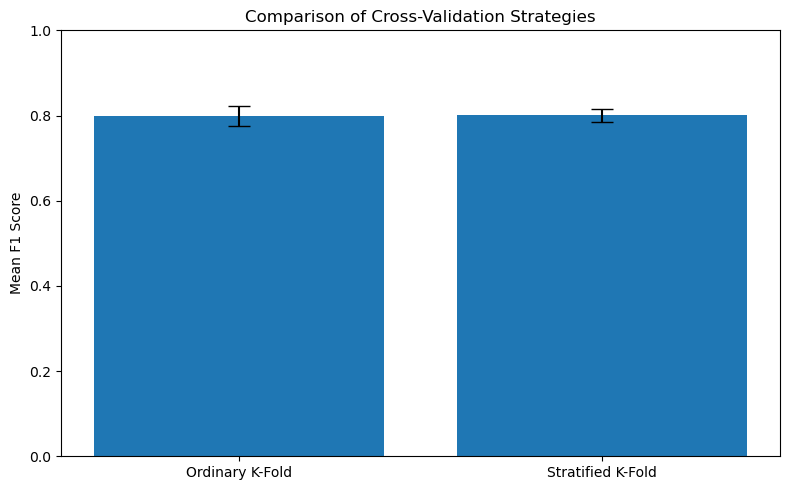

In [74]:
x = np.arange(2)

means = [
    ordinary_kfold_scores.mean(),
    cv_scores.mean()
]

stds = [
    ordinary_kfold_scores.std(),
    cv_scores.std()
]

plt.figure(figsize=(8, 5))

plt.bar(
    ["Ordinary K-Fold", "Stratified K-Fold"],
    means,
    yerr=stds,
    capsize=8
)

plt.title("Comparison of Cross-Validation Strategies")
plt.ylabel("Mean F1 Score")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()